In [1]:
import pandas as pd
import numpy as np
from models import cmre, nmre, ndee, ocsvm
from models_ds import cmre_ds, cmre_ds_adjusted_for_z
from plots import plot_appendix, plot_main_paper
import pickle

In [2]:
RESULTS_DIR = 'sensitivity_analysis_results_1'

# Simulation 6 Experiments

In [ ]:
def generate_sgc_datasets(x1_true_upcoding_rate, x1_true_downcoding_rate,
                          x2_true_upcoding_rate, x2_true_downcoding_rate,
                          x1_sa_normal, x2_sa_normal,
                          x1_sa_untrustworthy, x2_sa_untrustworthy,
                          x1_causal_effect_on_y, x2_causal_effect_on_y):

    # Load dataset
    df = pd.read_excel('./datasets/default_of_credit_card_clients.xls', skiprows=1)
    df = df.sample(frac=1).reset_index(drop=True)

    # Drop rows that are not needed
    df = df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']]

    # Convert sex to binary variable
    df['SEX'] = df['SEX'] - 1

    # Convert marriage to binary variable
    df['MARRIAGE'] = np.where(df['MARRIAGE'] > 1, 1, 0)

    # Convert education to binary variable
    df['EDUCATION'] = np.where(df['EDUCATION'] > 2, 1, 0)

    # Min-max scale the data
    df['AGE'] = (df['AGE'] - df['AGE'].min()) / (df['AGE'].max() - df['AGE'].min())
    
    # Keeping it simple by including no selection bias in agent_prob for now
    agent_prob = 0.3
    df['AGENT'] = np.random.binomial(1, agent_prob, len(df))
    
    # Generate employment variable
    x1_prob = 0.05 \
                    + df['EDUCATION']*0.05 \
                    + df['MARRIAGE']*df['SEX']*0.3 \
                    + np.square(df['AGE'])*0.1 \
                    + df['AGENT'] * x1_sa_untrustworthy + (1-df['AGENT'])*x1_sa_normal
    df['X1'] = np.random.binomial(1, x1_prob, len(df))

    # not making C affect X2 for now
    x2_prob = 0.2 + df['AGENT'] * x2_sa_untrustworthy + (1-df['AGENT'])*x2_sa_normal
    df['X2'] = np.random.binomial(1, x2_prob, len(df)) # X2 = X2* so far

    # muskaan comment: te i.e., x1_causal_effect_on_y, is beta(x) in the paper
    y_prob = 0.05 \
                    + df['EDUCATION']*0.05 \
                    + df['MARRIAGE']*df['SEX']*0.3 \
                    + np.square(df['AGE'])*0.1 \
                    + df['X1'] * x1_causal_effect_on_y \
                    + df['X2'] * x2_causal_effect_on_y
    df['Y'] = np.random.binomial(1, y_prob, len(df))

    # Strategically misreport the dataset (misreported employment status)
    x1_prob_required_for_upcoding_rate = ((x1_prob / (1-x1_true_upcoding_rate)) - x1_prob) / (1 - x1_prob)
    x1_prob_required_for_downcoding_rate = (((1 - x1_prob) / (1-x1_true_downcoding_rate)) - (1 - x1_prob)) / x1_prob

    x2_prob_required_for_upcoding_rate = ((x2_prob / (1-x2_true_upcoding_rate)) - x2_prob) / (1 - x2_prob)
    x2_prob_required_for_downcoding_rate = (((1 - x2_prob) / (1-x2_true_downcoding_rate)) - (1 - x2_prob)) / x2_prob

    df['X1'] = (df['X1'] + df['AGENT']*(1-df['X1']) * np.random.binomial(1, x1_prob_required_for_upcoding_rate,  len(df))
                        - df['X1']*(1-df['AGENT']) * np.random.binomial(1, x1_prob_required_for_downcoding_rate, len(df)))
    
    df['X2'] = (df['X2'] + df['AGENT']*(1-df['X2']) * np.random.binomial(1, x2_prob_required_for_upcoding_rate,  len(df))
                        - df['X2']*(1-df['AGENT']) * np.random.binomial(1, x2_prob_required_for_downcoding_rate, len(df))) # now Z != Z*

    return df

# Sensitivity Analysis Results On Semi-Synthetic Loan Data

### Vary Genuine Adaptation of A onto X2*

In [4]:
num_sims = 7

x2_sa_untrustworthy_list = [0.1, 0.2, 0.3, 0.4]

x1_true_upcoding_rate = 0.20
x1_true_downcoding_rate = 0.10
x2_true_upcoding_rate = 0.15
x2_true_downcoding_rate = 0.10

x1_sa_normal = 0.05
x2_sa_normal = 0.15
x1_sa_untrustworthy = 0.2
x1_causal_effect_on_y = 0.2
x2_causal_effect_on_y = 0.1


# Dataframes to keep track of results
cmre_ds_control_for_nothing = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])
cmre_ds_control_for_x2 = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])
cmre_ds_ground_truth = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])

# Perform a few simulations for each method
for sim in range(num_sims):
    # Set the random seed
    np.random.seed(sim)
    
    for x2_sa_untrustworthy in x2_sa_untrustworthy_list:

        # Generate dataset for simulation
        df = generate_sgc_datasets(x1_true_upcoding_rate, x1_true_downcoding_rate,
                          x2_true_upcoding_rate, x2_true_downcoding_rate,
                          x1_sa_normal, x2_sa_normal,
                          x1_sa_untrustworthy, x2_sa_untrustworthy,
                          x1_causal_effect_on_y, x2_causal_effect_on_y)

        normal_dataset = df[df['AGENT'] == 0]
        strategic_dataset = df[df['AGENT'] == 1]
        
        # Get misreporting rates and keep track of results
        mr = cmre_ds('X1', 'Y', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset) # the data stitching version of CMRE
        cmre_ds_control_for_nothing.loc[len(cmre_ds_control_for_nothing)] = [sim, x2_sa_untrustworthy, mr]

        mr = cmre_ds_adjusted_for_z('X1', 'X2', 'Y', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset) # the data stitching version of CMRE
        cmre_ds_control_for_x2.loc[len(cmre_ds_control_for_x2)] = [sim, x2_sa_untrustworthy, mr]

        cmre_ds_ground_truth.loc[len(cmre_ds_ground_truth)] = [sim, x2_sa_untrustworthy, x1_true_upcoding_rate]

# Get mean and std for each causal effect
cmre_ds_control_for_nothing = cmre_ds_control_for_nothing.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()
cmre_ds_control_for_x2 = cmre_ds_control_for_x2.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()
cmre_ds_ground_truth = cmre_ds_ground_truth.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()

In [5]:
# Save info
vary_genuine_adaptation_a_on_x2_star = [cmre_ds_control_for_nothing,
                       cmre_ds_control_for_x2,
                       cmre_ds_ground_truth]
with open(f'{RESULTS_DIR}/vary_genuine_modification_of_a_on_x2_star.pkl', 'wb') as f:
    pickle.dump(vary_genuine_adaptation_a_on_x2_star, f)

# Create plots

In [6]:
# Load lists
with open(f'{RESULTS_DIR}/vary_genuine_modification_of_a_on_x2_star.pkl', 'rb') as f:
    vary_genuine_adaptation_a_on_x2_star = pickle.load(f)

In [7]:
print(vary_genuine_adaptation_a_on_x2_star[0])
print(vary_genuine_adaptation_a_on_x2_star[1])
print(vary_genuine_adaptation_a_on_x2_star[2])

    sa      mean       std
0  0.1  0.235620  0.056044
1  0.2  0.161619  0.069787
2  0.3  0.043734  0.136712
3  0.4  0.081468  0.156008
    sa      mean       std
0  0.1  0.266505  0.059352
1  0.2  0.244214  0.049831
2  0.3  0.169775  0.084817
3  0.4  0.290037  0.073850
    sa  mean  std
0  0.1   0.2  0.0
1  0.2   0.2  0.0
2  0.3   0.2  0.0
3  0.4   0.2  0.0


In [8]:
import matplotlib.pyplot as plt

def plot_sensitivity_analysis(df_array,
                label_list,
                true_mr_list,
                x_var_list,
                x_label_list,
                y_label):
    
    plt.rcParams['text.usetex'] = False
    colors = ['#ff7f00', '#377eb8', '#4daf4a', '#f781bf', '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']

    fig, axs = plt.subplots(1, len(x_label_list), figsize=(16, 4))
    
    for exp_num in range(len(x_label_list)):
        true_mr = true_mr_list[exp_num]
        x_var = x_var_list[exp_num]
        x_label = x_label_list[exp_num]

        for i in range(len(label_list)):
            df_results = df_array[exp_num][i]
            label = label_list[i]
            axs[exp_num].errorbar(df_results[x_var], df_results['mean'], 
                               yerr=df_results['std'], fmt='o',
                               label=label, capsize=5, color=colors[i])
        
        if x_var == 'true_mr':
            xy1 = (df_array[exp_num][0]['true_mr'].iloc[0], df_array[exp_num][0]['true_mr'].iloc[0])
            xy2 = (df_array[exp_num][0]['true_mr'].iloc[-1], df_array[exp_num][0]['true_mr'].iloc[-1])
            axs[exp_num].axline(xy1=xy1, xy2=xy2, color='grey', linestyle='--')
            axs[exp_num].set_xlabel(x_label, fontsize=20, fontweight='bold')
            axs[exp_num].grid(True)
        else:
            axs[exp_num].axhline(y=true_mr, color='grey', linestyle='--')
            axs[exp_num].set_xlabel(x_label, fontsize=20, fontweight='bold')
            axs[exp_num].grid(True)
        
        axs[exp_num].tick_params(axis='x', labelsize=20)
        axs[exp_num].tick_params(axis='y', labelsize=20)
    
    axs[0].set_ylabel(y_label, fontsize=20, fontweight='bold')
    
    axs[0].legend(
        loc='upper left',
        bbox_to_anchor=(-0.25, -0.25),
        ncol=6,
        fontsize=18,
    )

    return plt

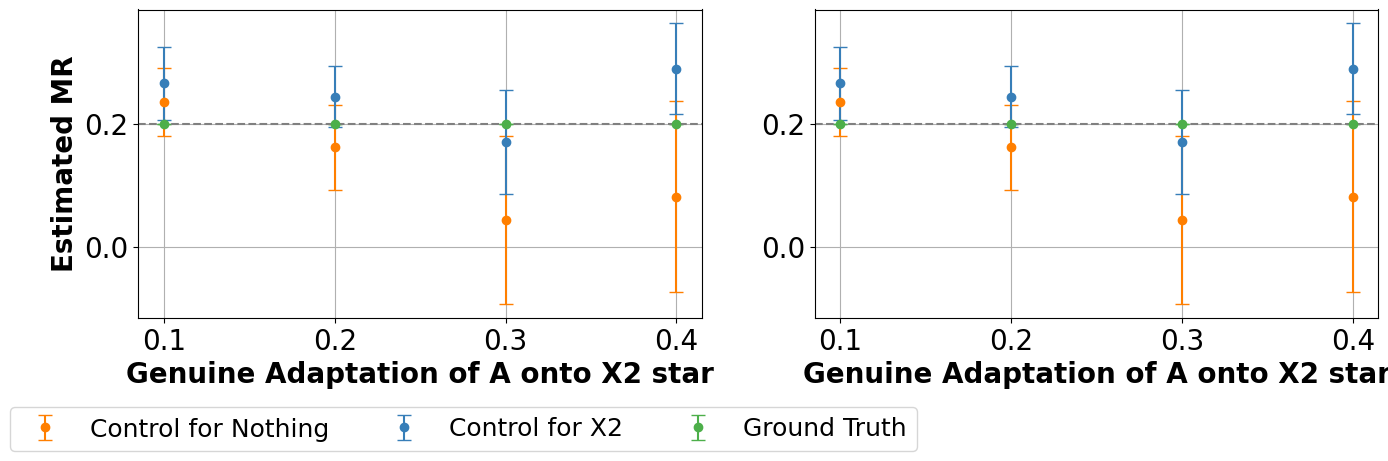

In [ ]:
# Create and show plot
synth_list = [vary_genuine_adaptation_a_on_x2_star, vary_genuine_adaptation_a_on_x2_star]
synth_mr_list = [0.2, 0.2] # ground truth misreporting rate
label_list = ['Control for Nothing', 'Control for X2', 'Ground Truth']
x_var_list = ['sa', 'sa']
x_label_list = ['Genuine Adaptation of A onto X2 star', 'Genuine Adaptation of A onto X2 star']
y_label = 'Estimated MR'

plt = plot_sensitivity_analysis(synth_list,
                label_list,
                synth_mr_list,
                x_var_list,
                x_label_list,
                y_label)


# plt.show()
plt.savefig(f'{RESULTS_DIR}/vary_genuine_modification_of_a_on_x2star.pdf', dpi=600, bbox_inches='tight')